## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [3]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import matplotlib.pyplot as plt
from dataset_preparation import awgn
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

In [4]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'

RX_NODES_V2 = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]
DATA_CONFIG_V2 = {
    'dataset_name': DatasetAPI.DATASET_V2,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 100,
    'samples_count': 400
}

AUG_CONFIG = {
    'multiplier': 5,
    't_rms_bounds': matlab.double([1, 2]),
    'd_f_bounds': matlab.double([0, 10]),
    'k_factor_bounds': matlab.double([0, 10]),
    'awgn': matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size': 32,
    # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
    'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
    #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
    # 'loss_type': 'n_loss', 'loss_num_neg': 2,
    'npair_type': 'samedev',
    # 'npair_type': 'diffdev',
    'alpha': 1.0, # used only for triple & quadruple loss
    'patience': 10,
    'fp_len': 512,
    'row': 50
}

In [5]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES_V2, 
    data_config=DATA_CONFIG_V2, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=False)

### 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

Load the training dataset
Processing offset 0
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.0%
Processing offset 10
29/29 [==============================] - 1s 2ms/step
Accuracy: 91.78%
Processing offset 20
29/29 [==============================] - 0s 2ms/step
Accuracy: 96.67%
Processing offset 30
29/29 [==============================] - 0s 2ms/step
Accuracy: 94.67%
Processing offset 40
29/29 [==============================] - 0s 2ms/step
Accuracy: 95.44%
Processing offset 50
29/29 [==============================] - 0s 2ms/step
Accuracy: 99.0%
Processing offset 60
29/29 [==============================] - 0s 2ms/step
Accuracy: 92.89%
Processing offset 70
29/29 [==============================] - 0s 2ms/step
Accuracy: 94.33%
Processing offset 80
29/29 [==============================] - 0s 2ms/step
Accuracy: 83.67%
Processing offset 90
29/29 [==============================] - 0s 2ms/step
Accuracy: 83.0%
Processing offset 100
29/29 [==============================] - 0s 2m

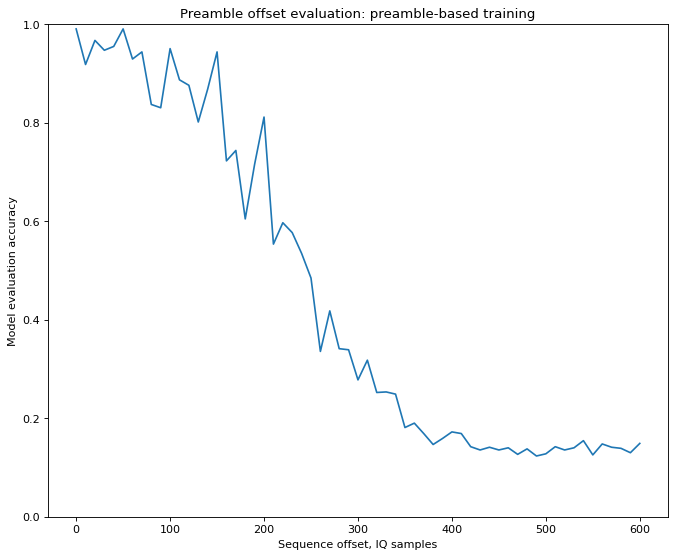

Load the training dataset
Applying quadruplet_loss
Epoch 1/1000


2024-08-30 16:50:32.492294: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa2eb5819e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-08-30 16:50:32.492342: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-30 16:50:32.492354: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-30 16:50:32.492373: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-30 16:50:32.496315: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1725051032.580130 1842916 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 [==============================] - 8s 22ms/step - loss: 1.5012 - val_loss: 1.4996 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.4975 - val_loss: 1.4932 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 1.4784 - val_loss: 1.4577 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.4817 - val_loss: 1.4864 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 21ms/step - loss: 1.4619 - val_loss: 1.4709 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 4s 22ms/step - loss: 1.4667 - val_loss: 1.4097 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 17ms/step - loss: 1.4331 - val_loss: 1.4229 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.3981 - val_loss: 1.3267 - lr: 0.0010
Epoch 9/1000
163/163 [==============================] - 3s 18ms/step - loss: 1.3272 -

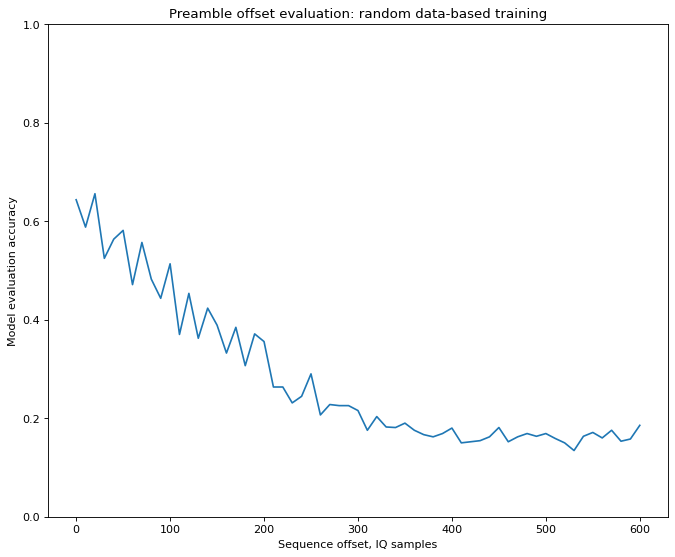

In [7]:
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, frame_start_train=0, offset_range=np.arange(0, 610, 10), use_pretrained=True, fig_name="Preamble offset evaluation: preamble-based training")
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, frame_start_train=400, offset_range=np.arange(0, 610, 10), use_pretrained=False, fig_name="Preamble offset evaluation: random data-based training")

### 2. Triplet vs. quadruplet training loss function

This is a simple task to compare the performance of the closed set and open set problems while models are being via two different loss functions.

Load the training dataset
Evaluating for triplet_loss
Applying triplet_loss
Epoch 1/1000
163/163 [==============================] - 4s 15ms/step - loss: 0.1390 - val_loss: 0.0497 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 17ms/step - loss: 0.0247 - val_loss: 0.0088 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 2s 14ms/step - loss: 0.0115 - val_loss: 0.0080 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 19ms/step - loss: 0.0049 - val_loss: 0.0048 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 2s 15ms/step - loss: 0.0031 - val_loss: 0.0040 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0024 - val_loss: 0.0020 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 2s 14ms/step - loss: 0.0019 - val_loss: 6.2366e-04 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0012 - val_loss: 1.3524e-04 -

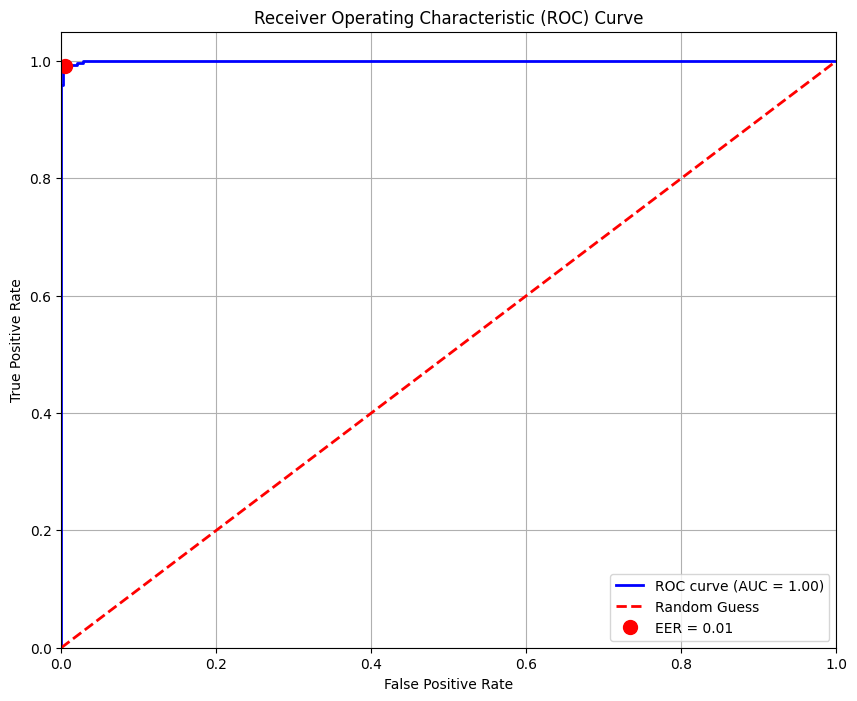

Evaluating for quadruplet_loss
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 20ms/step - loss: 0.3902 - val_loss: 0.1693 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 19ms/step - loss: 0.1242 - val_loss: 0.0887 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0767 - val_loss: 0.0778 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0550 - val_loss: 0.0491 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0359 - val_loss: 0.0341 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0249 - val_loss: 0.0224 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0160 - val_loss: 0.0118 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0105 - val_loss: 0.0024 - lr: 0.0010
Epoch 9/1000
163

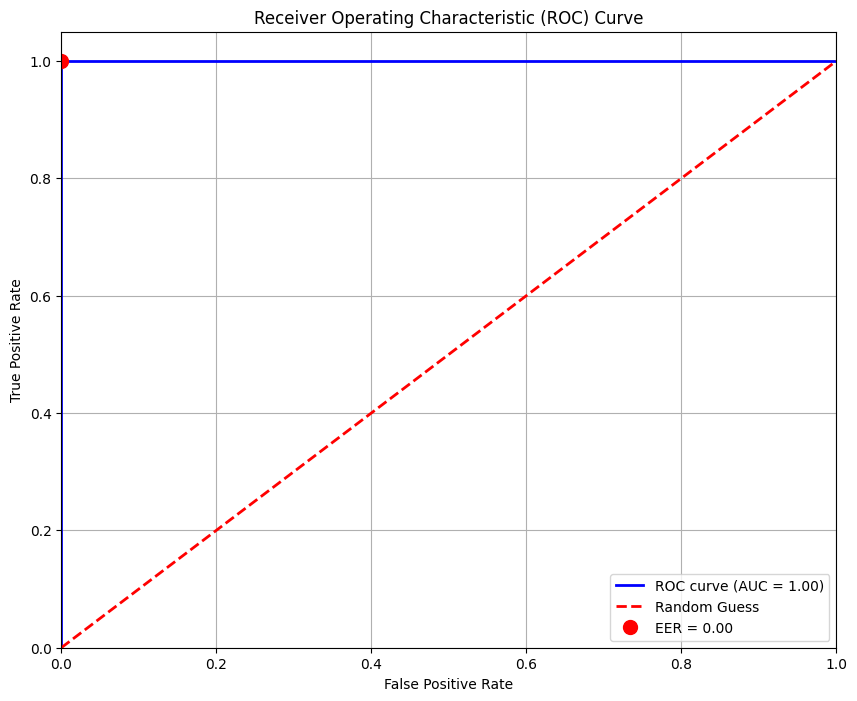

In [17]:
eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, render_confusion_matrix = True, render_roc_curve = True)

### 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
171
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node1-20...
171
29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node20-1...
171
29/29 [==============================] - 0s 2ms/step
./home/smazokha2016/Desktop/orbit_dataset_v2_jul19/node20-1_epoch_2024-07-20_18-32-46.h5
index 0 is out of bounds for axis 0 with size 0
.

Traceback (most recent call last):
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/evaluation_api.py", line 254, in _produce_fingerprints
    for k in np.arange(data_fps_reshaped.shape[1]):
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/dataset_api.py", line 164, in filter_dataset
    frame_idx_device = np.where(labels==int(dev_idx))[0][pkt_range]
IndexError: index 0 is out of bounds for axis 0 with size 0


29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node19-19...
171
29/29 [==============================] - 1s 2ms/step


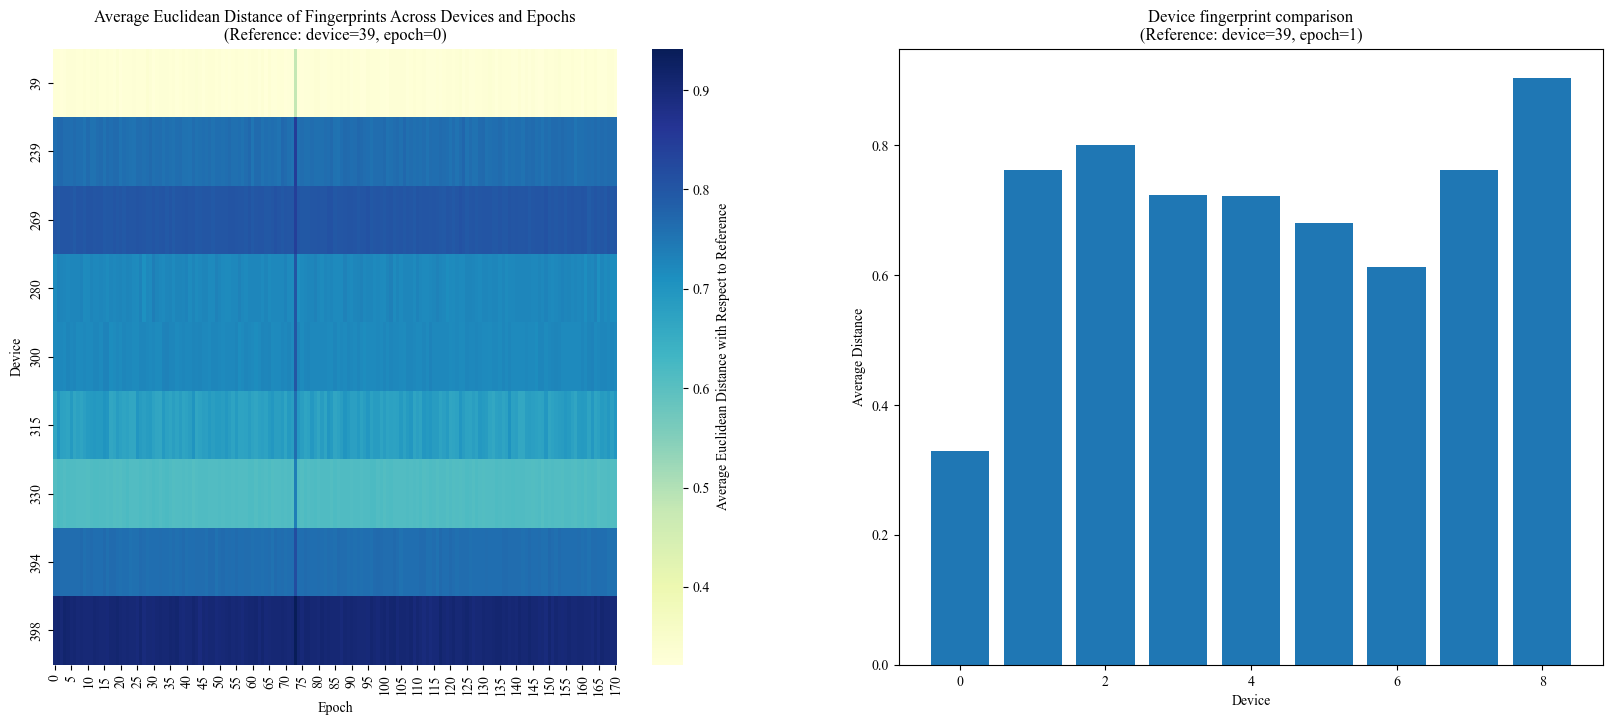

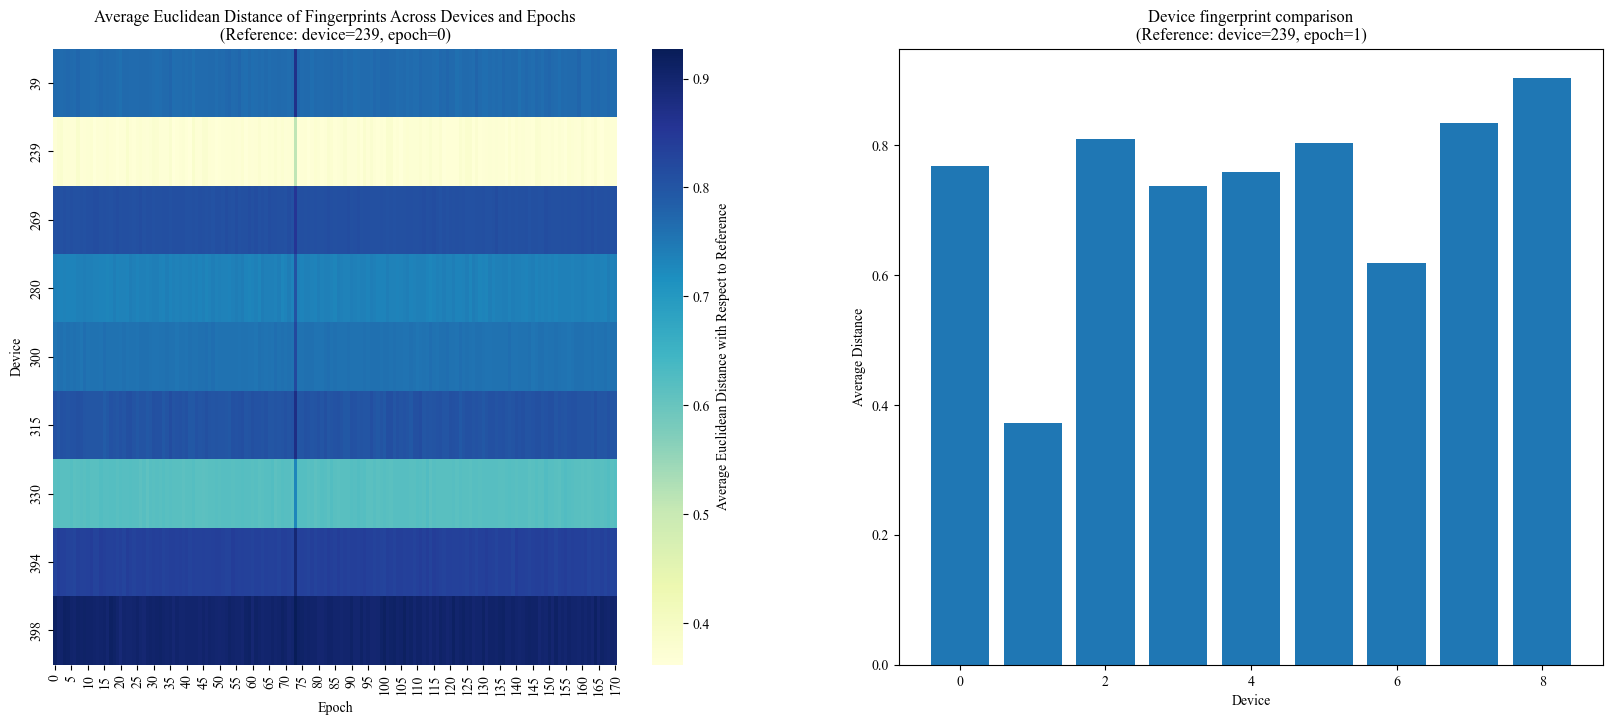

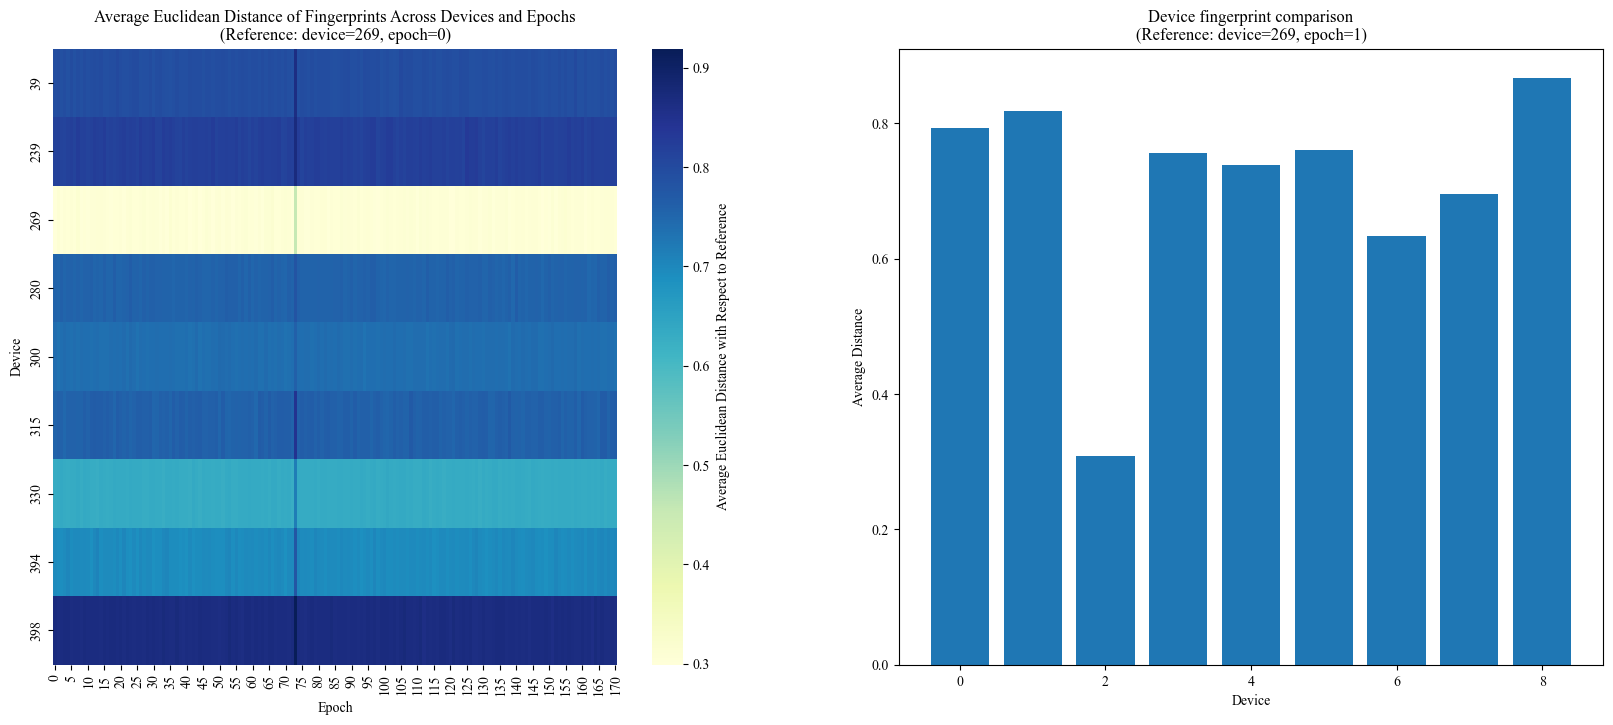

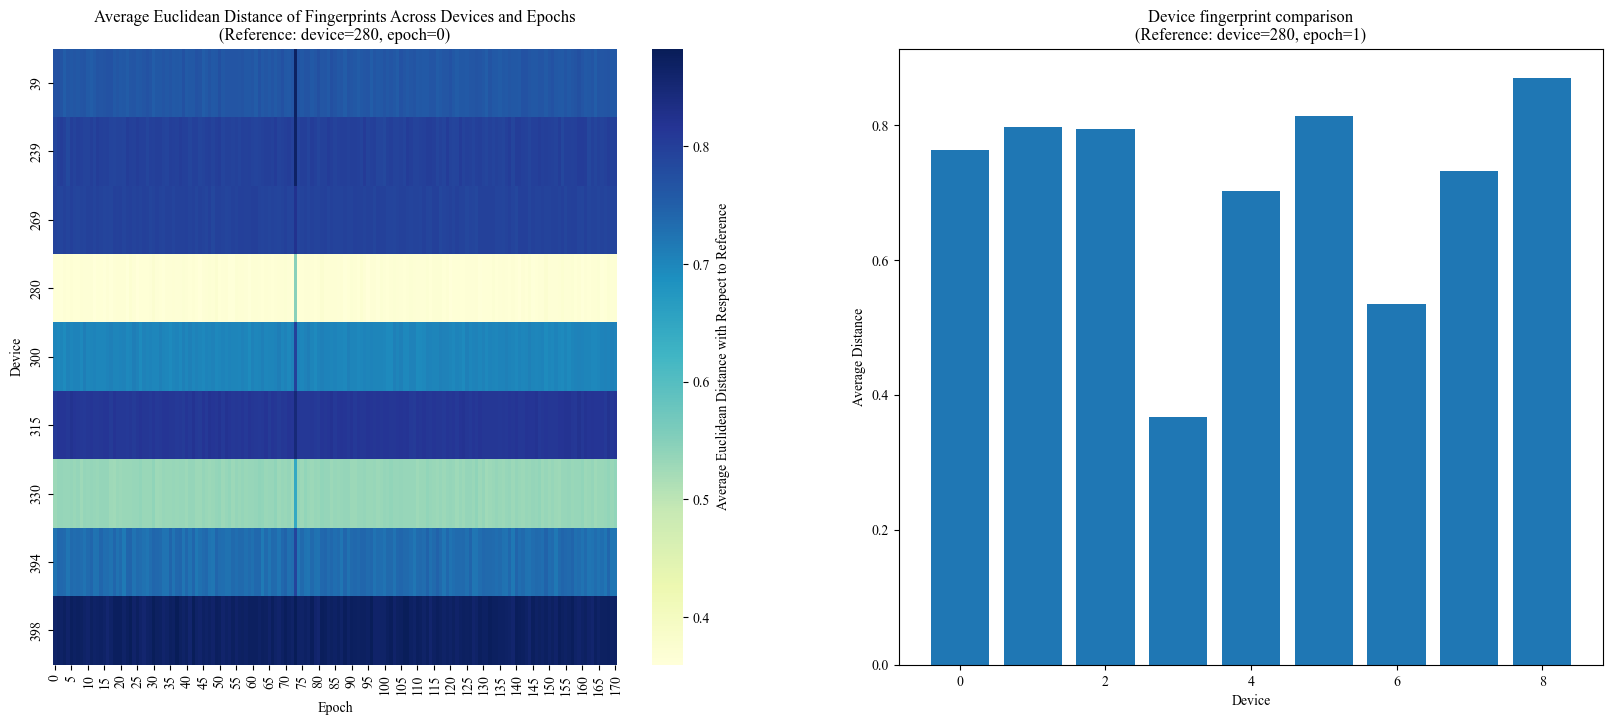

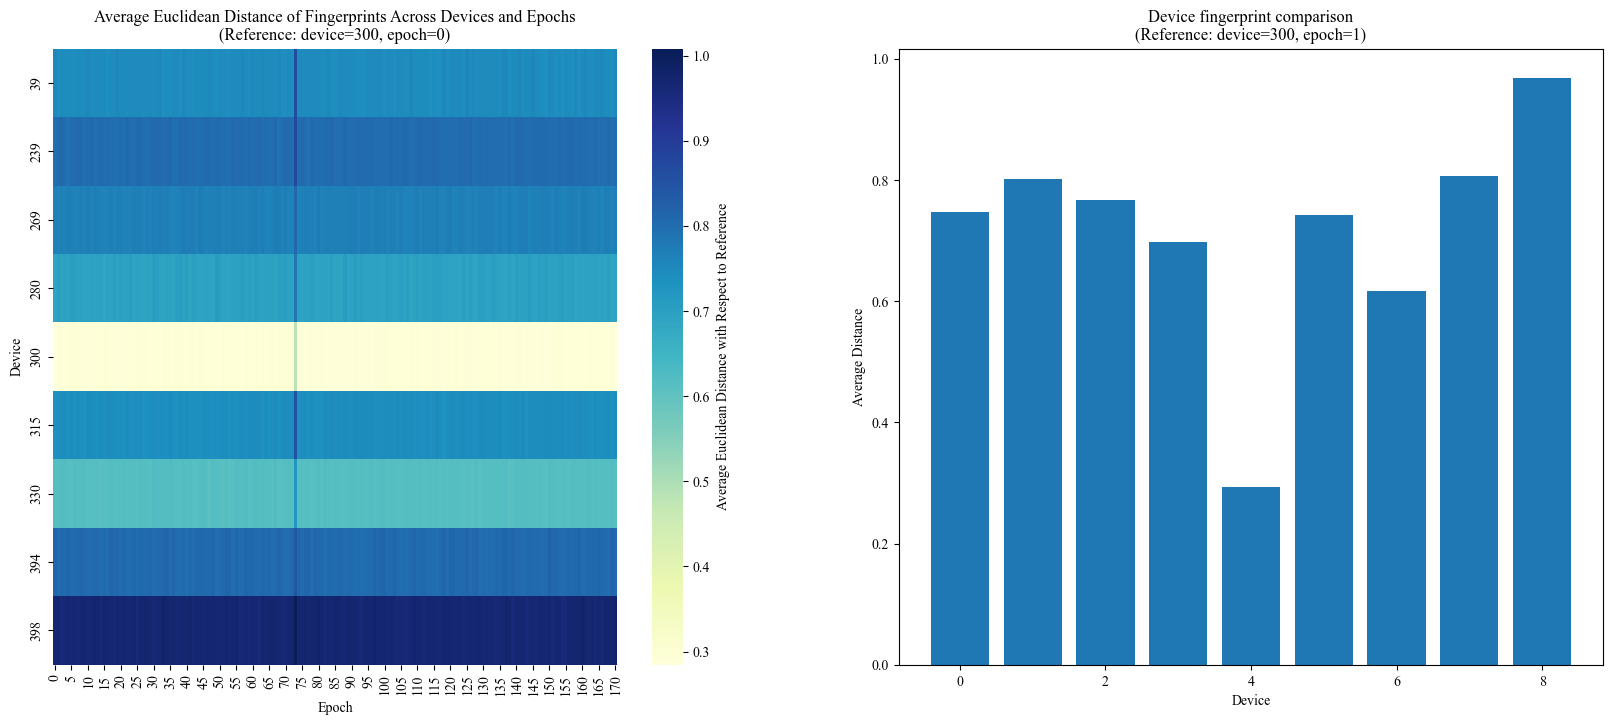

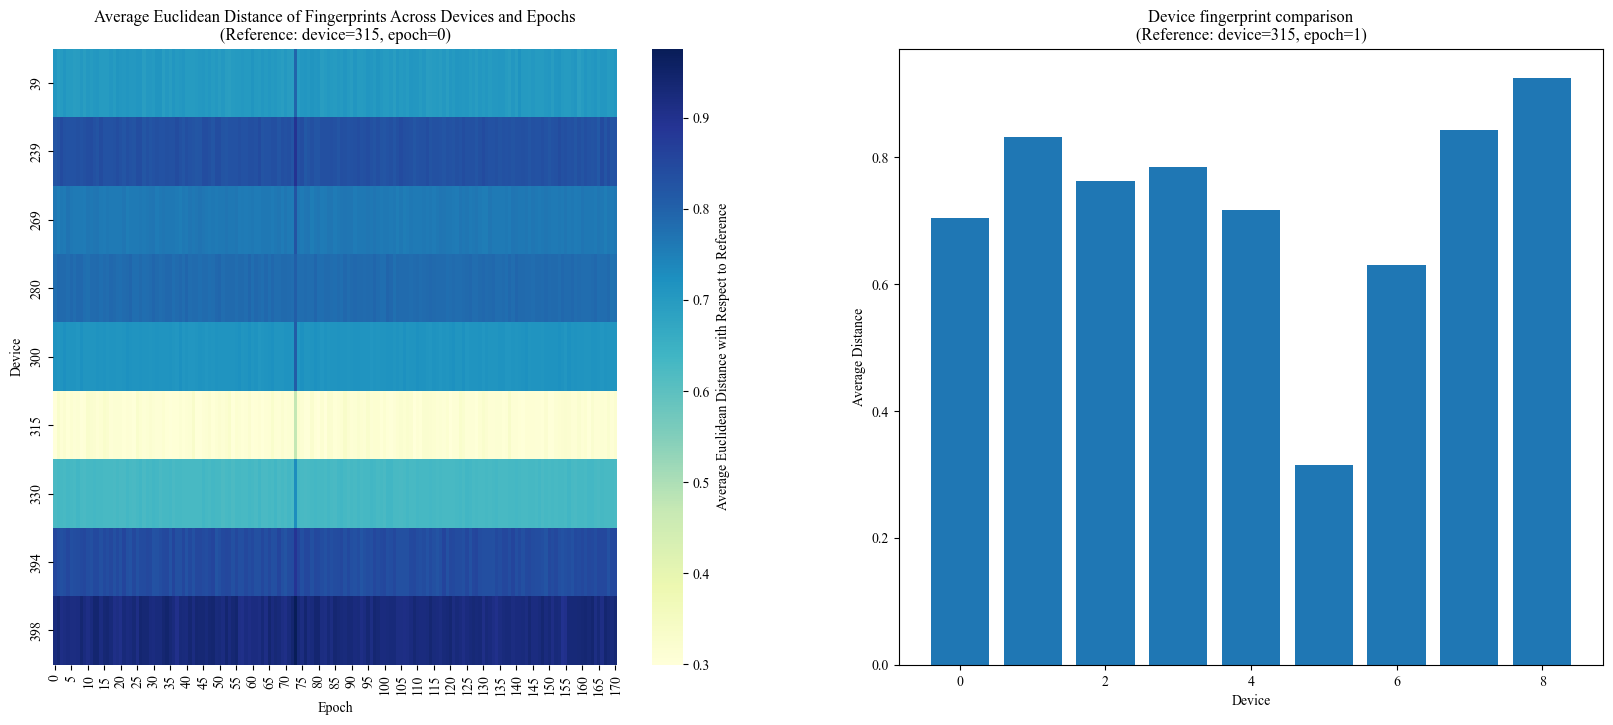

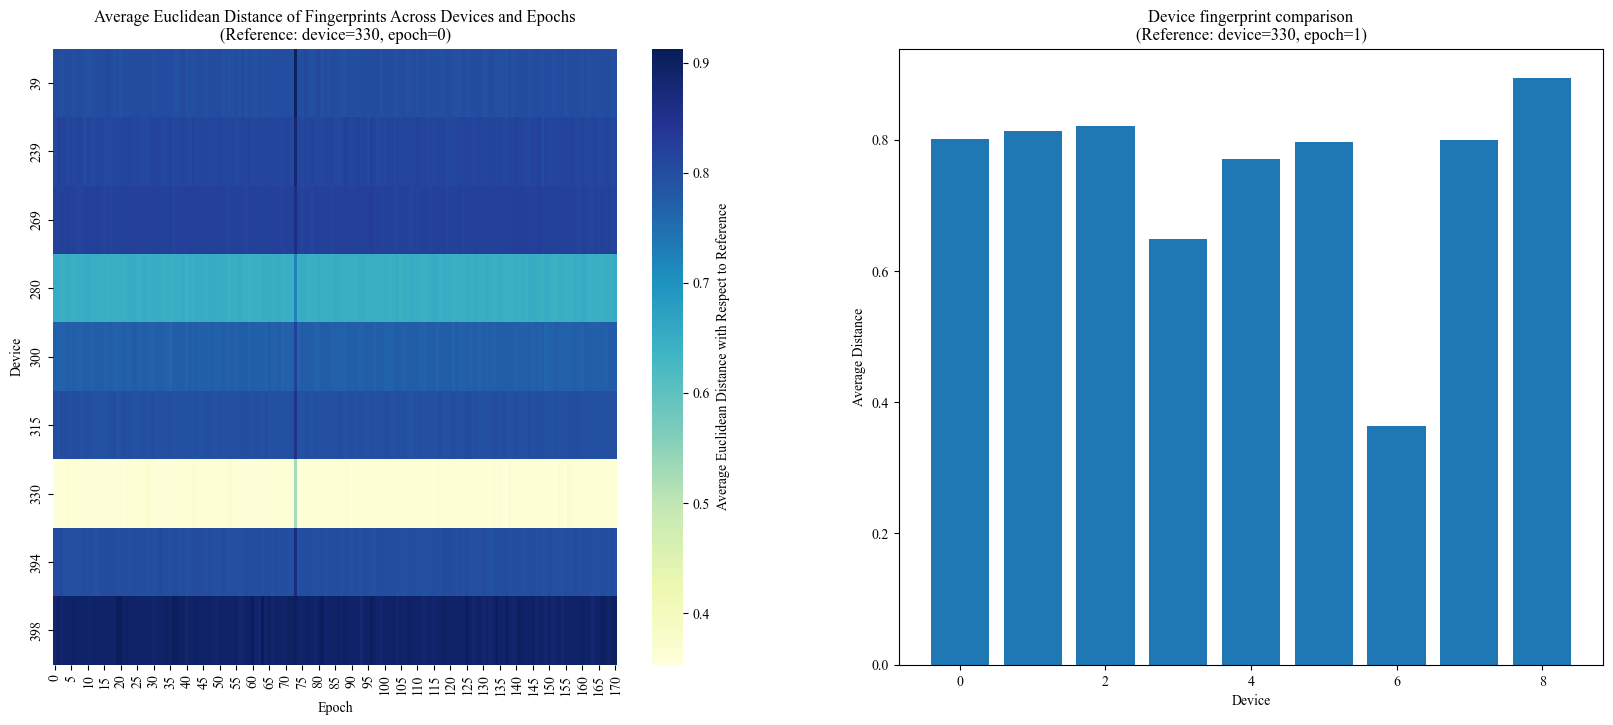

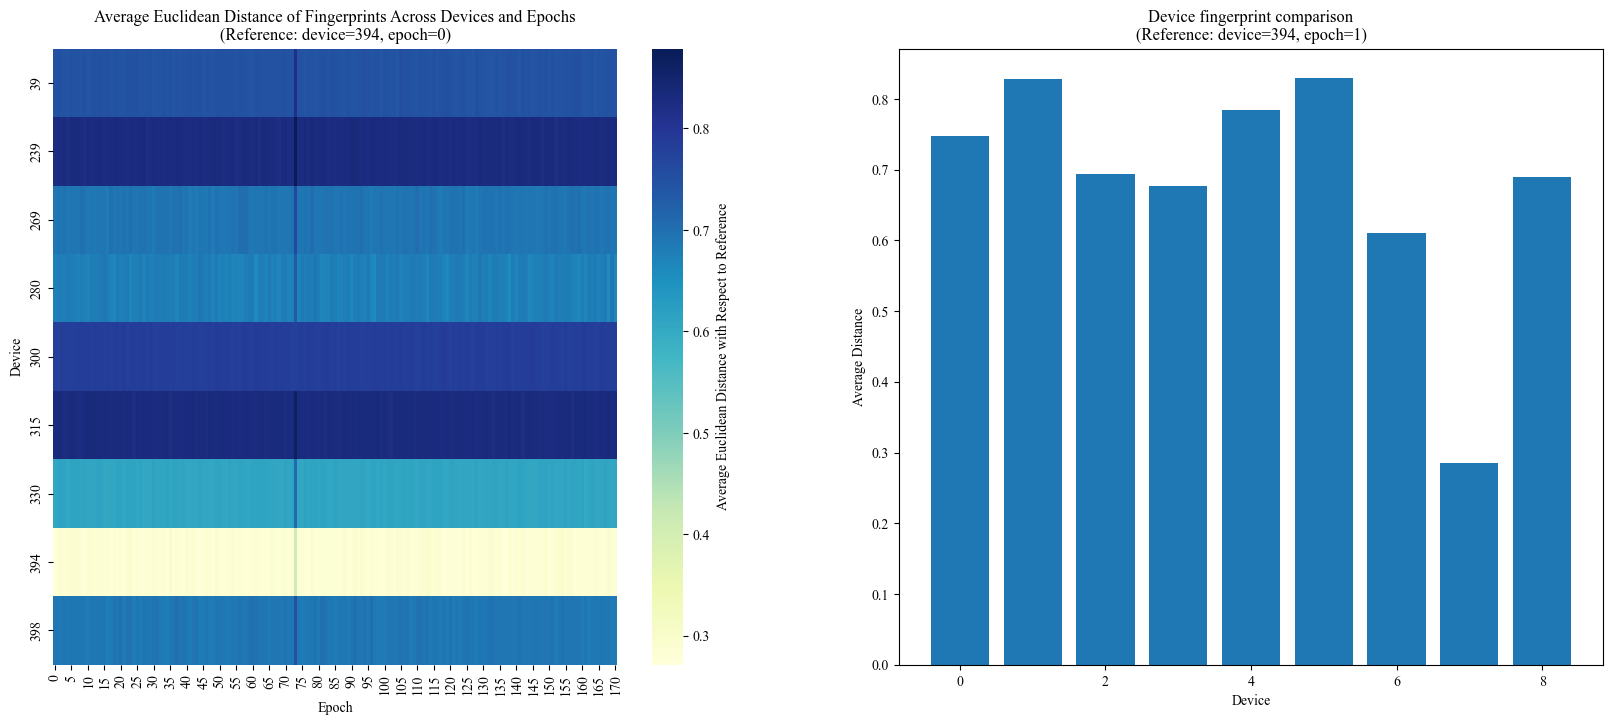

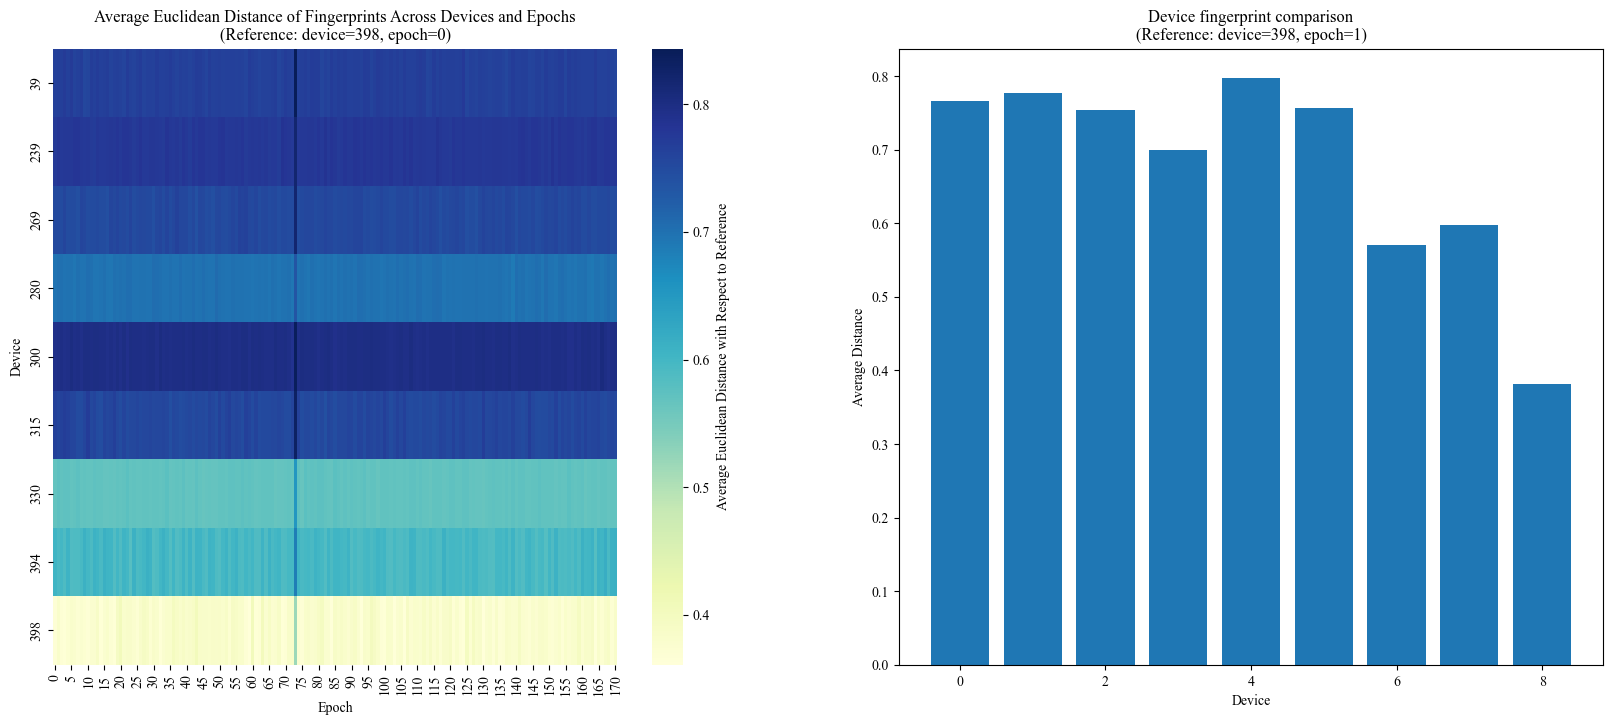

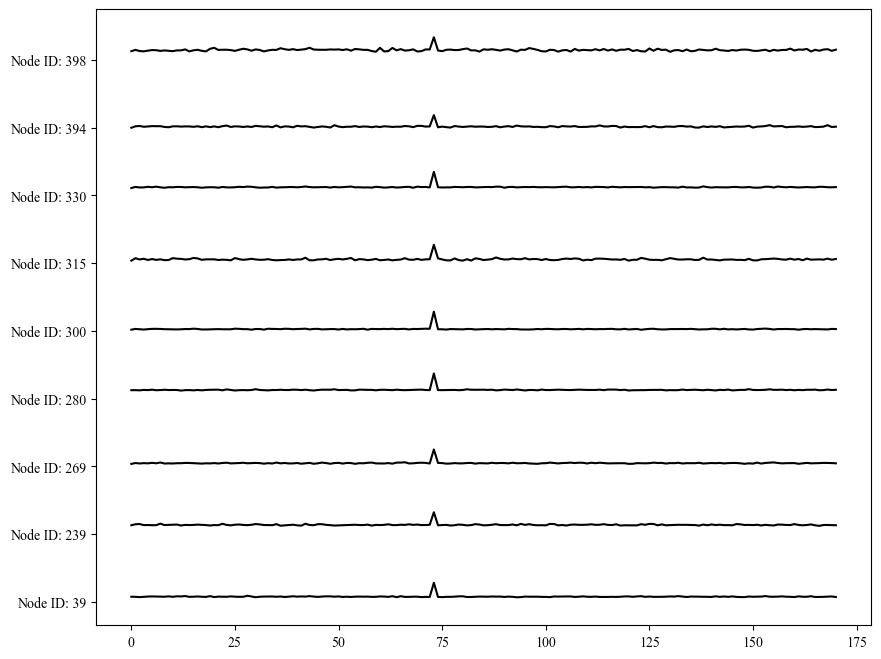

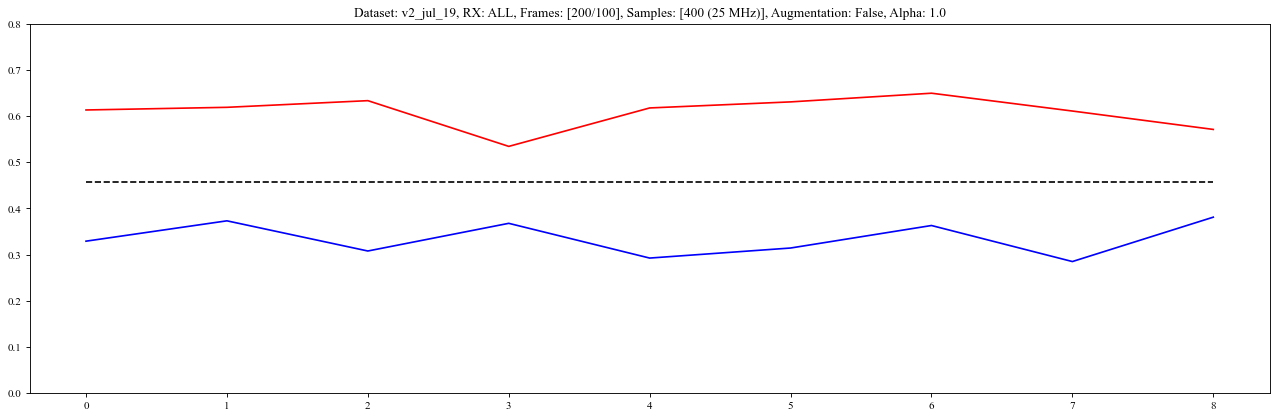

In [21]:
# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

node_ids_epoch_override=[39, 239, 269, 280, 300, 315, 330, 394, 398]

fp_distances = eval_api.evaluate_temporal_stability(models, RX_NODES_V2, node_ids_epoch_override, epochs_override=None, show_fp_heatmaps=True)

### 4. Multi-RX fingerprinting

### 5. Dataset confusion matrices

Load the training dataset
Evaluating for quadruplet_loss
Applying quadruplet_loss
Epoch 1/1000
163/163 [==============================] - 6s 20ms/step - loss: 0.4477 - val_loss: 0.1947 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.1571 - val_loss: 0.1068 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0982 - val_loss: 0.0729 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 17ms/step - loss: 0.0676 - val_loss: 0.0523 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0449 - val_loss: 0.0366 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 3s 20ms/step - loss: 0.0344 - val_loss: 0.0244 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 21ms/step - loss: 0.0211 - val_loss: 0.0133 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 4s 22ms/step - loss: 0.0147 - val_loss: 0.0071 - l

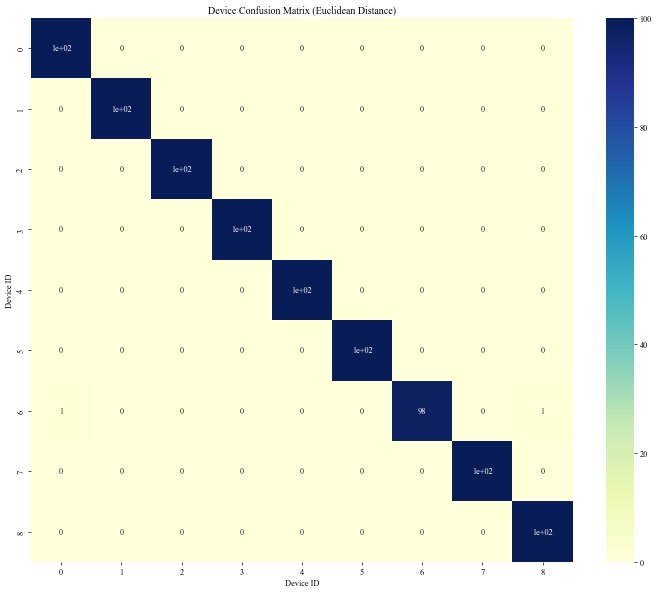

Accuracy: 99.78%


In [23]:
accuracies = eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, loss_functions=['quadruplet_loss'], render_confusion_matrix=True)